# Fama-French Multi-Factor Model Analysis

This notebook extends the original single-factor CAPM beta analysis by adding the **Fama-French multi-factor models**.

---

## 📚 Introduction: Beyond CAPM — The Fama-French Models

### Why CAPM Isn't Enough

The original Capital Asset Pricing Model (CAPM) explains a stock's expected return using just **one factor**: its sensitivity to the overall market (`beta`). While simple and elegant, decades of empirical research showed that CAPM leaves a lot of return variation unexplained. Certain groups of stocks — small companies, "cheap" companies — consistently earned higher returns than CAPM predicted. These patterns are called **anomalies**.

Eugene Fama and Kenneth French set out to capture these anomalies in a systematic way.

---

### The Fama-French 3-Factor Model (FF3)

Published in 1993, the FF3 model adds two additional risk factors to CAPM:

$$\text{Return}_t - R_f = \alpha + \beta_{\text{mkt}}(R_m - R_f) + \beta_{\text{SMB}} \cdot SMB_t + \beta_{\text{HML}} \cdot HML_t + \varepsilon_t$$

| Factor | Full Name | What It Captures |
|--------|-----------|------------------|
| `Mkt-RF` | Market minus Risk-Free Rate | Systematic market risk (same as CAPM beta) |
| `SMB` | **Small Minus Big** | Return of small-cap stocks minus large-cap stocks. A positive SMB loading means the stock behaves like a small-cap. |
| `HML` | **High Minus Low** | Return of high book-to-market stocks minus low book-to-market stocks. Also called the *value premium*. Positive HML loading = value stock; negative = growth stock. |

**Intuition for SMB:** Small companies have historically outperformed large companies over the long run, possibly because they are riskier and less liquid. SMB captures this size premium.

**Intuition for HML:** "Value" stocks (high book-to-market, i.e., cheap relative to assets) have historically outperformed "growth" stocks (low book-to-market). HML captures this value premium.

---

### The Fama-French 5-Factor Model (FF5)

Published in 2015, the FF5 model adds two more factors to FF3:

$$\text{Return}_t - R_f = \alpha + \beta_{\text{mkt}}(R_m - R_f) + \beta_{\text{SMB}} \cdot SMB + \beta_{\text{HML}} \cdot HML + \beta_{\text{RMW}} \cdot RMW + \beta_{\text{CMA}} \cdot CMA + \varepsilon_t$$

| Factor | Full Name | What It Captures |
|--------|-----------|------------------|
| `RMW` | **Robust Minus Weak** | Return of stocks with robust (high) profitability minus weak (low) profitability. Also called the *profitability factor*. |
| `CMA` | **Conservative Minus Aggressive** | Return of stocks with conservative (low) investment minus aggressive (high) investment. Also called the *investment factor*. |

**Intuition for RMW:** Companies with high operating profitability have historically outperformed low-profitability companies.

**Intuition for CMA:** Companies that invest conservatively (low asset growth) have historically outperformed those that invest aggressively.

---

### Where to Get the Factor Data

Kenneth French maintains a free data library at:
> **https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html**

The datasets we use in this notebook:
- **FF3 Monthly**: `Fama/French 3 Factors` → download the CSV inside the ZIP file
- **FF5 Monthly**: `Fama/French 5 Factors (2x3)` → download the CSV inside the ZIP file

The factor returns are expressed as **percentages** in the raw files (e.g., `0.64` means `0.64%`). We divide by 100 to convert to decimals to match the scale of our stock returns.

Alternatively, the `pandas_datareader` library can download these factors directly:
```python
import pandas_datareader.data as web
ff3 = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='2021-01')
```

In this notebook we **download directly from French's website** using `requests` — no extra library needed.

---

### Workflow Overview

| Step | What we do |
|------|------------|
| 1 | Import libraries |
| 2 | Scrape S&P 500 constituents from Wikipedia |
| 3 | Download 5 years of adjusted close prices from Yahoo Finance |
| 4 | Convert daily prices → monthly returns |
| 5 | Download Fama-French factor data |
| 6 | Merge stock returns with factor data |
| 7 | Define regression functions (CAPM, FF3, FF5) |
| 8 | Run all regressions across all stocks |
| 9 | Visualise and compare results |


## 1. Import Libraries

| Library | Role |
|---------|------|
| `requests` | HTTP requests — fetches Wikipedia HTML and Fama-French ZIP files |
| `zipfile` / `io` | Unzips the Fama-French data in memory (no need to save to disk) |
| `BeautifulSoup` | Parses raw HTML into a Python-navigable tree |
| `pandas` | Core data manipulation: DataFrames, resampling, merging, groupby |
| `datetime` | Date objects for defining our download window |
| `yfinance` | Yahoo Finance wrapper — downloads historical price data |
| `numpy` | Numerical operations (sqrt, NaN handling) |
| `statsmodels` | OLS regression with R-style formula syntax |
| `matplotlib` | Base plotting library |
| `seaborn` | High-level statistical charts |
| `time` | Measures regression runtime |

In [15]:
# ── Web scraping ──────────────────────────────────────────────────────────────
import requests                        # HTTP requests
import zipfile                         # Unzip Fama-French files in memory
import io                              # In-memory byte buffers
from bs4 import BeautifulSoup          # HTML parser

# ── Data manipulation ─────────────────────────────────────────────────────────
import pandas as pd                    # DataFrames — core data tool
from datetime import date              # Date objects for the download window

# ── Finance data ──────────────────────────────────────────────────────────────
import yfinance as yf                  # Yahoo Finance API wrapper

# ── Numerical & statistical ───────────────────────────────────────────────────
import numpy as np                     # Numerical operations
import statsmodels.formula.api as smf  # OLS regression

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt        # Base plotting library
import seaborn as sns                  # Statistical visualisations
import plotly.express as px            # interactive visualisations
import plotly.graph_objects as go

# ── Utilities ─────────────────────────────────────────────────────────────────
import time                            # Timer

print("Libraries loaded.")

Libraries loaded.


## 2. Scrape S&P 500 Constituents from Wikipedia

We pull the live S&P 500 constituent list from Wikipedia so the analysis always reflects the current index.

**Steps:**
1. `requests.get()` fetches the page HTML
2. `BeautifulSoup` parses the HTML tree
3. We locate the table by its HTML `id='constituents'`
4. `pd.read_html()` converts the HTML table into a DataFrame

> 🎯 **GICS Sector** — a standardised industry taxonomy used by S&P. We'll use it for sector-level aggregation later.

In [3]:
url     = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'StockAnalyzer/2.0 (example@example.com)'}  # polite bot ID

# Fetch and parse the Wikipedia page
response   = requests.get(url, headers=headers)
soup       = BeautifulSoup(response.content, 'html.parser')

# Locate the specific table with id='constituents'
table_tag  = soup.find('table', {'id': 'constituents'})

# pd.read_html() converts HTML → DataFrame; [0] selects the first (only) table
constituents_table = pd.read_html(io.StringIO(str(table_tag)))[0]

# Keep only the columns we need and rename for clarity
constituents_df = (
    constituents_table
    .rename(columns={
        'Symbol':          'ticker',
        'GICS Sector':     'industry',
        'GICS Sub-Industry': 'sub-industry'
    })
    [['ticker', 'Security', 'industry', 'sub-industry']]
)

print(f"S&P 500 constituents loaded: {len(constituents_df)} stocks")
constituents_df.head()

S&P 500 constituents loaded: 503 stocks


,ticker,Security,industry,sub-industry
0,MMM,3M,Industrials,Industrial Conglomerates
1,AOS,A. O. Smith,Industrials,Building Products
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment
3,ABBV,AbbVie,Health Care,Biotechnology
4,ACN,Accenture,Information Technology,IT Consulting & Other Services


## 3. Download Historical Price Data from Yahoo Finance

We download **5 years of adjusted close prices** for every S&P 500 stock plus SPY (our market proxy).

**Why adjusted close prices?**  
Raw prices can drop on dividend payment days even though the shareholder isn't losing money. Adjusted prices retroactively correct for dividends and splits, giving a clean series of true investor returns.

> ⚠️ This cell makes a large network request — it may take 30–60 seconds.

In [4]:
# Build the full ticker list: S&P 500 stocks + SPY as the market benchmark
tickers_to_download = constituents_df['ticker'].tolist() + ['SPY']

# Dynamic date range: always 5 years back from today
end_date   = date.today()
start_date = date(end_date.year - 5, 1, 1)  # 1 Jan, five years ago

print(f"Downloading {len(tickers_to_download)} tickers from {start_date} to {end_date}...")

# yf.download() fetches all tickers in one API call
# auto_adjust=False  → keep raw prices so we can select 'Adj Close' explicitly
# progress=False     → suppress the progress bar for cleaner output
adj_close_df = yf.download(
    tickers_to_download,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)['Adj Close']

print(f"Downloaded. Shape: {adj_close_df.shape}  (rows=trading days, cols=tickers)")
adj_close_df.head()

$BF.B: possibly delisted; no price data found  (1d 2021-01-01 -> 2026-03-22)
$BRK.B: possibly delisted; no timezone found

2 Failed downloads:
['BF.B']: possibly delisted; no price data found  (1d 2021-01-01 -> 2026-03-22)
['BRK.B']: possibly delisted; no timezone found


Downloaded. Shape: (1309, 504)  (rows=trading days, cols=tickers)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,114.659744,125.856689,86.047401,139.149994,99.184891,33.186359,238.710403,485.339996,133.391068,43.059490,...,26.590872,103.679459,55.615074,33.693790,93.735970,221.160004,95.962547,142.740280,378.130005,155.735611
2021-01-05,115.597214,127.412773,86.937180,148.300003,100.412079,33.319485,240.069382,485.690002,135.775330,43.897030,...,26.842113,106.870346,55.072979,35.317589,93.623146,229.750000,95.971603,145.209930,380.570007,156.820877
2021-01-06,118.767166,123.123863,86.186172,142.770004,100.203018,34.783871,242.694168,466.309998,136.387360,45.675697,...,26.979889,107.510452,56.292679,36.218796,97.572281,226.889999,96.497597,149.347900,394.820007,159.124664
2021-01-07,121.927467,127.325264,87.108604,151.270004,101.175674,34.460564,244.983917,477.739990,142.151642,45.269890,...,27.239235,106.443588,55.191566,36.502960,102.000984,239.479996,95.763039,148.462509,409.100006,158.981888
2021-01-08,122.797249,128.424240,87.565704,149.770004,101.457474,34.650742,245.877472,485.100006,143.183929,45.390770,...,27.052832,105.745277,55.699772,36.908905,100.966675,241.449997,97.168655,148.136337,405.470001,160.038605


## 4. Compute Monthly Returns

**Why monthly?**  
Daily returns are noisy — full of one-day idiosyncratic moves unrelated to the factors. Monthly returns are the standard in academic finance for factor model estimation: they filter out noise while still providing ~60 data points over 5 years.

**Pipeline:**
```
Daily adj. close prices
  │
  ▼  .resample('ME').last()   → last trading-day price each month
Month-end prices
  │
  ▼  .pct_change()            → (this month − last month) / last month
Monthly returns (NaN in row 0)
  │
  ▼  .iloc[1:]                → drop NaN row
Clean monthly returns ✓
```

In [5]:
monthly_returns_wide = (
    adj_close_df
    .resample('ME').last()     # last available price each calendar month
    .pct_change()              # month-over-month return
    .iloc[1:]                  # drop first row (no prior month → NaN return)
    .rename(columns={'SPY': 'SPY_Return'})  # self-documenting column name
)

print(f"Monthly returns shape: {monthly_returns_wide.shape}")
print(f"Date range: {monthly_returns_wide.index[0].date()} to {monthly_returns_wide.index[-1].date()}")
monthly_returns_wide.head()

Monthly returns shape: (62, 504)
Date range: 2021-02-28 to 2026-03-31


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-28,0.015811,-0.079712,0.051327,0.123727,-0.030828,0.140401,0.037120,0.001962,0.062156,0.139282,...,0.085925,0.323521,-0.084388,0.233125,0.033673,0.065151,0.024990,0.061105,0.287755,0.006418
2021-03-31,0.041534,0.007340,0.004455,-0.089217,0.000501,0.071189,0.101036,0.034155,-0.004749,0.007423,...,0.056434,-0.048281,0.143644,0.026853,0.056448,-0.012955,0.044915,-0.016781,-0.028533,0.014429
2021-04-30,0.052724,0.076218,0.042836,-0.081036,0.005682,0.034923,0.052914,0.069357,-0.012381,0.107544,...,0.089045,0.024168,0.072019,0.025255,0.052006,0.078265,0.104825,0.106697,0.005276,0.100380
2021-05-31,0.033598,-0.050497,0.015247,-0.187077,-0.028564,0.004533,-0.026934,-0.007397,0.079237,0.059653,...,-0.020893,0.027025,-0.005891,0.034597,0.070076,-0.091087,0.007948,-0.049842,0.019088,0.021094
2021-06-30,0.070079,0.099109,-0.004947,0.090741,-0.006173,-0.023816,0.044762,0.160649,0.045929,-0.089133,...,-0.089155,-0.072571,-0.064380,0.080692,0.015577,0.095632,-0.041177,-0.043218,0.065265,0.054788


## 5. Download Fama-French Factor Data

We download the factor data directly from Kenneth French's data library at Dartmouth.

**URL pattern:**  
French publishes ZIP files. Each ZIP contains a CSV with the factor returns.

**What we do:**
1. Download the ZIP file into memory (no disk write needed)
2. Open the ZIP and find the CSV inside
3. Parse the CSV, skipping the copyright header
4. Convert the `YYYYMM` date index to a proper month-end `DatetimeIndex`
5. Divide by 100 (factors are in percent, our stock returns are in decimals)

> 📌 The FF5 dataset contains all the FF3 factors **plus** RMW and CMA, so we only need to download one file for the 5-factor model.

### What is the Risk-Free Rate (`RF`)?
French uses the **1-month US Treasury bill rate** as the risk-free rate. Factor regressions use **excess returns** (stock return minus RF), not raw returns. This is important: a stock that returns 0.5%/month when the risk-free rate is also 0.5% has zero alpha.

In [6]:
def load_ff_factors(url: str) -> pd.DataFrame:
    """
    Download a Fama-French factor ZIP file from French's website and return
    a DataFrame with monthly factor returns as decimals (not percentages).

    Parameters
    ----------
    url : str
        Direct URL to the ZIP file on French's data library.

    Returns
    -------
    pd.DataFrame
        Monthly factor returns indexed by month-end dates.
    """
    # ── Step 1: Download the ZIP file into memory ─────────────────────────────
    response = requests.get(url)
    zip_buffer = io.BytesIO(response.content)  # wrap bytes as a file-like object

    # ── Step 2: Open the ZIP and extract the CSV ──────────────────────────────
    with zipfile.ZipFile(zip_buffer) as z:
        # The CSV file is always the first (and only) non-directory entry
        csv_name = [f for f in z.namelist() if f.endswith('.CSV') or f.endswith('.csv')][0]
        with z.open(csv_name) as csv_file:
            content = csv_file.read().decode('utf-8', errors='replace')

    # ── Step 3: Find the start of the data ────────────────────────────────────
    # French's CSV files begin with a text header before the actual data.
    # We look for the first line that starts with a year (4 digits).
    lines = content.splitlines()
    data_start = 0
    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped and stripped[0].isdigit() and len(stripped.split(',')[0].strip()) == 6:
            data_start = i - 1  # the line before is the header
            break

    # ── Step 4: Parse the CSV into a DataFrame ────────────────────────────────
    df = pd.read_csv(
        io.StringIO('\n'.join(lines[data_start:])),
        index_col=0           # first column is the YYYYMM date
    )

    # Strip whitespace from column names (French's files sometimes have spaces)
    df.columns = df.columns.str.strip()
    df.index   = df.index.astype(str).str.strip()

    # ── Step 5: Keep only rows with a valid 6-digit YYYYMM date ──────────────
    # The file may contain annual summary rows at the end — filter them out.
    df = df[df.index.str.match(r'^\d{6}$')]

    # ── Step 6: Convert the date index to proper month-end DatetimeIndex ─────
    # pd.to_datetime understands 'YYYYMM' with format '%Y%m'.
    # We then offset to month-end so dates align with our stock return dates.
    df.index = pd.to_datetime(df.index, format='%Y%m') + pd.offsets.MonthEnd(0)

    # ── Step 7: Convert from percent to decimal ───────────────────────────────
    # French stores returns as percent (e.g. 0.64 means 0.64%).
    # Our stock returns are in decimal (0.0064). Divide by 100 to match.
    df = df.apply(pd.to_numeric, errors='coerce') / 100

    return df


# ── Download FF5 factors (includes all FF3 factors + RMW + CMA) ───────────────
# We use FF5 for both models: FF3 uses a subset of the same columns.
FF5_URL = (
    'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
    'F-F_Research_Data_5_Factors_2x3_CSV.zip'
)

print("Downloading Fama-French 5-Factor data...")
ff5_factors = load_ff_factors(FF5_URL)

print(f"FF5 factors shape: {ff5_factors.shape}")
print(f"Columns: {list(ff5_factors.columns)}")
print(f"Date range: {ff5_factors.index[0].date()} → {ff5_factors.index[-1].date()}")
ff5_factors.tail()

FF5 factors shape: (751, 6)
Columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
Date range: 1963-07-31 → 2026-01-31


,Mkt-RF,SMB,HML,RMW,CMA,RF
2025-09-30,0.0339,-0.0218,-0.0105,-0.0206,-0.0222,0.0033
2025-10-31,0.0196,-0.0130,-0.0310,-0.0521,-0.0403,0.0037
2025-11-30,-0.0013,0.0147,0.0376,0.0142,0.0068,0.0030
2025-12-31,-0.0036,-0.0022,0.0242,0.0040,0.0037,0.0034
2026-01-31,0.0102,0.0326,0.0370,0.0183,0.0181,0.0030


## 6. Merge Stock Returns with Factor Data

We need to align our stock return series with the factor data on the **same monthly dates**.  
We also compute **excess returns** (stock return minus the risk-free rate `RF`).

**Why excess returns?**  
Factor models explain how much *extra* return a stock earns beyond what you could get risk-free. If T-bills yield 0.5%/month, a stock returning 0.5%/month has zero excess return — it's doing no better than cash.

In [7]:
# ── Trim factor data to our stock return window ───────────────────────────────
# .reindex() aligns the factor dates to our stock return dates.
# Dates with no factor data become NaN (they'll be dropped in regression).
factors_aligned = ff5_factors.reindex(monthly_returns_wide.index)

# ── Compute excess stock returns ──────────────────────────────────────────────
# Excess return = stock return − risk-free rate
# We subtract RF from every stock column (RF is a single series).
rf_series = factors_aligned['RF']   # 1-month T-bill rate, monthly decimal

# Subtract RF from each stock column; skip SPY_Return (we handle it separately)
stock_cols = [c for c in monthly_returns_wide.columns if c != 'SPY_Return']
excess_returns_wide = monthly_returns_wide[stock_cols].subtract(rf_series, axis=0)

# Keep SPY_Return for CAPM; also compute excess market return for FF models
# 'Mkt-RF' is already excess market return in French's data — we use that directly.

print(f"Excess returns shape: {excess_returns_wide.shape}")
print(f"Factor columns available: {list(factors_aligned.columns)}")

# Confirm date overlap
common_dates = excess_returns_wide.index.intersection(factors_aligned.dropna().index)
print(f"Months with both stock returns and factor data: {len(common_dates)}")

Excess returns shape: (62, 503)
Factor columns available: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
Months with both stock returns and factor data: 60


## 7. Regression Functions

We define three regression functions — one for each model:

### Model 1: CAPM
$$\text{Stock Excess Return}_t = \alpha + \beta_{\text{mkt}} \cdot (R_m - R_f)_t + \varepsilon_t$$

### Model 2: Fama-French 3-Factor (FF3)
$$\text{Stock Excess Return}_t = \alpha + \beta_{\text{mkt}} \cdot \text{Mkt-RF}_t + \beta_{\text{SMB}} \cdot \text{SMB}_t + \beta_{\text{HML}} \cdot \text{HML}_t + \varepsilon_t$$

### Model 3: Fama-French 5-Factor (FF5)
$$\text{Stock Excess Return}_t = \alpha + \beta_{\text{mkt}} \cdot \text{Mkt-RF}_t + \beta_{\text{SMB}} \cdot \text{SMB}_t + \beta_{\text{HML}} \cdot \text{HML}_t + \beta_{\text{RMW}} \cdot \text{RMW}_t + \beta_{\text{CMA}} \cdot \text{CMA}_t + \varepsilon_t$$

**Data quality gate:** We require at least **35 monthly observations** for a reliable estimate. Stocks with fewer (e.g. recent IPOs) return all-NaN.

**Note on `Q("...")` syntax:** `statsmodels` formula syntax can choke on ticker symbols containing special characters like `.` (e.g. `BRK.B`). Wrapping the column name in `Q("...")` quotes it safely.

In [8]:
# ── Helper: build the regression DataFrame for one stock ──────────────────────
def _build_reg_df(stock_series, factor_df):
    """
    Align and clean data for one stock.
    Returns a DataFrame of (stock_excess_return, factors) with NaN rows dropped.
    """
    return pd.concat([stock_series, factor_df], axis=1).dropna()


# ── Model 1: CAPM ─────────────────────────────────────────────────────────────
def run_capm(stock_series, factor_df, min_obs=35):
    """
    Fit CAPM: Excess Return ~ Mkt-RF

    Parameters
    ----------
    stock_series : pd.Series  — monthly excess returns for one stock
    factor_df    : pd.DataFrame — factor data aligned to the same dates
    min_obs      : int  — minimum observations required (default 35)

    Returns
    -------
    pd.Series with keys: CAPM_Alpha, CAPM_Beta, CAPM_R2, CAPM_ResidSE
    """
    df = _build_reg_df(stock_series, factor_df[['Mkt-RF']])

    # Require at least min_obs paired observations; skip if too few
    if len(df) < min_obs:
        return pd.Series({
            'CAPM_Alpha': np.nan, 'CAPM_Beta': np.nan,
            'CAPM_R2': np.nan, 'CAPM_ResidSE': np.nan
        })

    # Q("...") quotes the column name so special characters (dots, spaces) are OK
    formula = f'Q("{stock_series.name}") ~ Q("Mkt-RF")'
    model   = smf.ols(formula=formula, data=df).fit()

    return pd.Series({
        'CAPM_Alpha':   model.params.get('Intercept', np.nan),
        'CAPM_Beta':    model.params.get('Q("Mkt-RF")', np.nan),
        'CAPM_R2':      model.rsquared,
        'CAPM_ResidSE': np.sqrt(model.mse_resid)
    })


# ── Model 2: Fama-French 3-Factor ─────────────────────────────────────────────
def run_ff3(stock_series, factor_df, min_obs=35):
    """
    Fit FF3: Excess Return ~ Mkt-RF + SMB + HML

    Three factors capture market risk, size risk, and value risk.
    """
    df = _build_reg_df(stock_series, factor_df[['Mkt-RF', 'SMB', 'HML']])

    if len(df) < min_obs:
        return pd.Series({
            'FF3_Alpha': np.nan, 'FF3_Beta_Mkt': np.nan,
            'FF3_Beta_SMB': np.nan, 'FF3_Beta_HML': np.nan,
            'FF3_R2': np.nan, 'FF3_ResidSE': np.nan
        })

    formula = f'Q("{stock_series.name}") ~ Q("Mkt-RF") + SMB + HML'
    model   = smf.ols(formula=formula, data=df).fit()

    return pd.Series({
        'FF3_Alpha':    model.params.get('Intercept', np.nan),
        'FF3_Beta_Mkt': model.params.get('Q("Mkt-RF")', np.nan),
        'FF3_Beta_SMB': model.params.get('SMB', np.nan),
        'FF3_Beta_HML': model.params.get('HML', np.nan),
        'FF3_R2':       model.rsquared,
        'FF3_ResidSE':  np.sqrt(model.mse_resid)
    })


# ── Model 3: Fama-French 5-Factor ─────────────────────────────────────────────
def run_ff5(stock_series, factor_df, min_obs=35):
    """
    Fit FF5: Excess Return ~ Mkt-RF + SMB + HML + RMW + CMA

    FF5 adds profitability (RMW) and investment (CMA) to FF3.
    """
    df = _build_reg_df(stock_series, factor_df[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']])

    if len(df) < min_obs:
        return pd.Series({
            'FF5_Alpha': np.nan, 'FF5_Beta_Mkt': np.nan,
            'FF5_Beta_SMB': np.nan, 'FF5_Beta_HML': np.nan,
            'FF5_Beta_RMW': np.nan, 'FF5_Beta_CMA': np.nan,
            'FF5_R2': np.nan, 'FF5_ResidSE': np.nan
        })

    formula = f'Q("{stock_series.name}") ~ Q("Mkt-RF") + SMB + HML + RMW + CMA'
    model   = smf.ols(formula=formula, data=df).fit()

    return pd.Series({
        'FF5_Alpha':    model.params.get('Intercept', np.nan),
        'FF5_Beta_Mkt': model.params.get('Q("Mkt-RF")', np.nan),
        'FF5_Beta_SMB': model.params.get('SMB', np.nan),
        'FF5_Beta_HML': model.params.get('HML', np.nan),
        'FF5_Beta_RMW': model.params.get('RMW', np.nan),
        'FF5_Beta_CMA': model.params.get('CMA', np.nan),
        'FF5_R2':       model.rsquared,
        'FF5_ResidSE':  np.sqrt(model.mse_resid)
    })


print("Regression functions defined.")

Regression functions defined.


## 8. Run All Three Regressions Across All Stocks

We use `.apply()` to run each model on every stock column simultaneously. This is conceptually a `for` loop over 500+ tickers but expressed as a single pandas operation.

**Why three separate `.apply()` calls?**  
Each model returns a different number of columns. Keeping them separate and merging at the end is cleaner.

> ⏱️ Running ~1,500 regressions (3 models × 500 stocks) takes roughly 5–10 seconds.

In [9]:
t0 = time.perf_counter()
print("Fitting CAPM regressions...")

# Run CAPM on every stock column
# .apply() calls run_capm once per column; .T transposes so stocks are rows
capm_results = (
    excess_returns_wide
    .apply(run_capm, factor_df=factors_aligned)
    .T
)

print("Fitting FF3 regressions...")
ff3_results = (
    excess_returns_wide
    .apply(run_ff3, factor_df=factors_aligned)
    .T
)

print("Fitting FF5 regressions...")
ff5_results = (
    excess_returns_wide
    .apply(run_ff5, factor_df=factors_aligned)
    .T
)

# ── Merge all results together ─────────────────────────────────────────────────
# pd.concat along columns axis — all three share the same ticker index
all_results = pd.concat([capm_results, ff3_results, ff5_results], axis=1)

# ── Add sector labels ──────────────────────────────────────────────────────────
# Merge with the constituents table on ticker symbol (index)
all_results = (
    all_results
    .merge(
        constituents_df.set_index('ticker'),
        left_index=True,
        right_index=True
    )
    .dropna(subset=['CAPM_Beta'])   # drop stocks where regression failed
)

t1 = time.perf_counter()
print(f"\nAll regressions complete. {len(all_results)} stocks in {t1 - t0:.1f} seconds.")
all_results.head()

Fitting CAPM regressions...
Fitting FF3 regressions...
Fitting FF5 regressions...

All regressions complete. 495 stocks in 3.3 seconds.


,CAPM_Alpha,CAPM_Beta,CAPM_R2,CAPM_ResidSE,FF3_Alpha,FF3_Beta_Mkt,FF3_Beta_SMB,FF3_Beta_HML,FF3_R2,FF3_ResidSE,...,FF5_Beta_Mkt,FF5_Beta_SMB,FF5_Beta_HML,FF5_Beta_RMW,FF5_Beta_CMA,FF5_R2,FF5_ResidSE,Security,industry,sub-industry
Ticker,,,,,,,,,,,,,,,,,,,,,
A,-0.008455,1.291319,0.485391,0.059337,-0.008275,1.279201,0.328565,0.208043,0.519421,0.058357,...,1.285526,0.327970,0.165059,-0.063886,0.104578,0.520288,0.059374,Agilent Technologies,Health Care,Life Sciences Tools & Services
AAPL,0.002277,1.051226,0.428144,0.054218,0.004385,1.013401,-0.109672,-0.336266,0.476010,0.052818,...,1.000608,0.043475,-0.419400,0.402876,-0.006737,0.494155,0.052848,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals"
ABBV,0.012910,0.302339,0.044259,0.062699,0.006247,0.441610,-0.403115,0.537550,0.157041,0.059926,...,0.452963,-0.230313,0.265761,0.198457,0.422084,0.182070,0.060113,AbbVie,Health Care,Biotechnology
ABNB,-0.013359,1.208806,0.243827,0.095001,-0.006361,1.057383,0.619635,-0.427004,0.279231,0.094392,...,1.095932,0.197444,-0.220461,-1.143216,0.073231,0.341732,0.091862,Airbnb,Consumer Discretionary,"Hotels, Resorts & Cruise Lines"
ABT,-0.007779,0.705404,0.291620,0.049064,-0.012651,0.810707,-0.426439,0.300830,0.351910,0.047760,...,0.828781,-0.329586,0.067676,-0.005072,0.431689,0.373595,0.047816,Abbott Laboratories,Health Care,Health Care Equipment


## 9a. Model Comparison — R² Improvement

A key measure of a model's explanatory power is **R²** (coefficient of determination): what fraction of a stock's return variance is explained by the model.

- **CAPM R²**: only market beta
- **FF3 R²**: market + size + value
- **FF5 R²**: market + size + value + profitability + investment

We expect FF5 ≥ FF3 ≥ CAPM in terms of R². The gap tells us how much additional variance is explained by the extra factors.

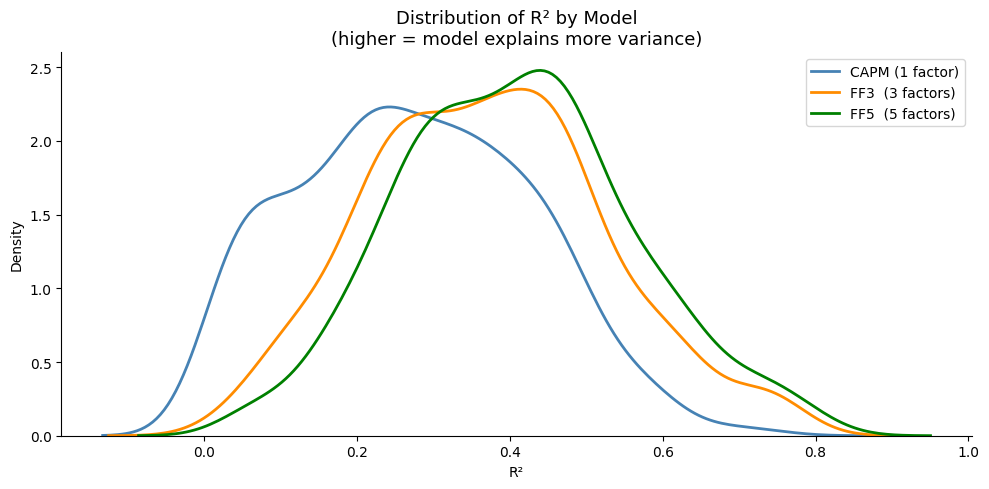


--- R² Summary Statistics ---


,CAPM_R2,FF3_R2,FF5_R2
count,495.000,495.000,495.000
mean,0.274,0.370,0.408
std,0.153,0.155,0.152
min,0.000,0.010,0.047
25%,0.151,0.255,0.300
50%,0.269,0.368,0.407
75%,0.387,0.469,0.501
max,0.735,0.774,0.818


In [10]:
# ── Plot R² distributions for all three models side by side ───────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Each column is one model's R² distribution; sns.kdeplot plots a smooth density
for col, label, color in [
    ('CAPM_R2', 'CAPM (1 factor)',      'steelblue'),
    ('FF3_R2',  'FF3  (3 factors)',     'darkorange'),
    ('FF5_R2',  'FF5  (5 factors)',     'green'),
]:
    sns.kdeplot(all_results[col].dropna(), label=label, color=color, linewidth=2, ax=ax)

ax.set_title('Distribution of R² by Model\n(higher = model explains more variance)', fontsize=13)
ax.set_xlabel('R²')
ax.set_ylabel('Density')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

# ── Summary statistics ─────────────────────────────────────────────────────────
r2_summary = all_results[['CAPM_R2', 'FF3_R2', 'FF5_R2']].describe().round(3)
print("\n--- R² Summary Statistics ---")
display(r2_summary)

## 9b. Alpha Comparison — Does Alpha Shrink with More Factors?

**Alpha (α)** is the intercept in the regression — the return a stock earns that is *not* explained by the model's factors.

- A positive alpha means the stock outperforms what the model predicts.
- If multi-factor models better describe risk, their alphas should be **smaller in magnitude** than CAPM alphas.

The intuition: CAPM attributes all size-premium returns to idiosyncratic alpha. FF3 instead recognises that small-cap stocks *should* earn higher returns as compensation for size risk — so the FF3 alpha for a small-cap stock will be lower than its CAPM alpha.

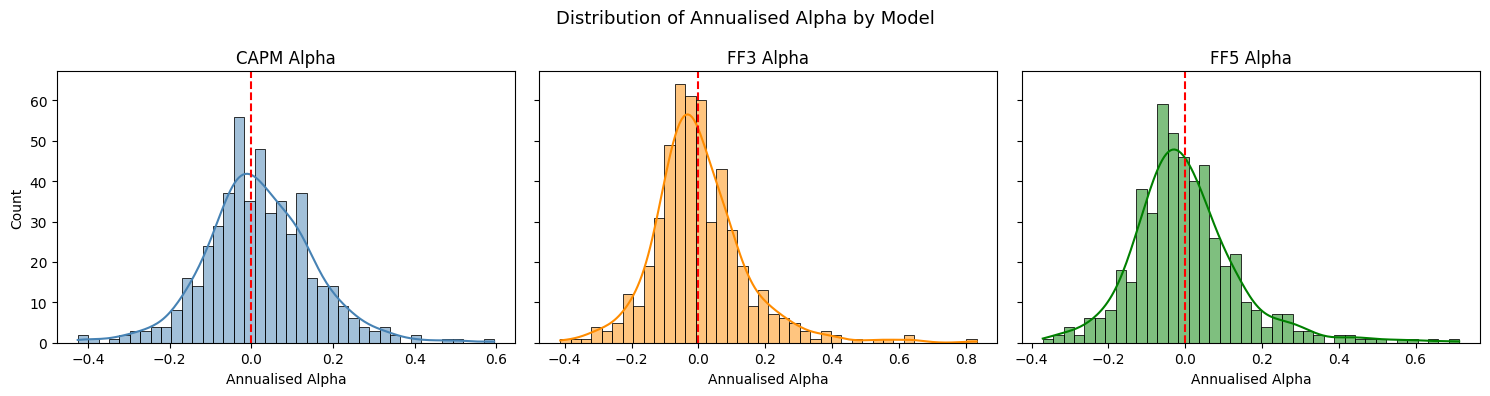


--- Annualised Alpha Summary ---


,CAPM_Alpha,FF3_Alpha,FF5_Alpha
count,495.0000,495.0000,495.0000
mean,0.0195,0.0026,0.0009
std,0.1323,0.1410,0.1413
min,-0.4251,-0.4134,-0.3713
25%,-0.0563,-0.0769,-0.0812
50%,0.0135,-0.0138,-0.0159
75%,0.1007,0.0680,0.0609
max,0.5945,0.8326,0.7137


In [11]:
# ── Annualise alpha (monthly alpha × 12) for easier interpretation ─────────────
# Monthly alpha of 0.3% corresponds to ~3.6% per year
annual_alpha = all_results[['CAPM_Alpha', 'FF3_Alpha', 'FF5_Alpha']].multiply(12)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, col, title, color in zip(
    axes,
    ['CAPM_Alpha', 'FF3_Alpha', 'FF5_Alpha'],
    ['CAPM Alpha', 'FF3 Alpha', 'FF5 Alpha'],
    ['steelblue', 'darkorange', 'green']
):
    # Histogram of annualised alphas
    sns.histplot(annual_alpha[col].dropna(), bins=40, color=color, ax=ax, kde=True)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)  # zero-alpha reference
    ax.set_title(title)
    ax.set_xlabel('Annualised Alpha')

axes[0].set_ylabel('Count')
fig.suptitle('Distribution of Annualised Alpha by Model', fontsize=13)
plt.tight_layout()
plt.show()

print("\n--- Annualised Alpha Summary ---")
display(annual_alpha.describe().round(4))

## 9c. Factor Loadings by Sector — SMB, HML, RMW, CMA

The sector-level factor loadings reveal how each GICS sector tilts toward size, value, profitability, and investment styles.

| Loading | What a positive value means |
|---------|------------------------------|
| `β_SMB > 0` | Sector behaves like *small caps* |
| `β_HML > 0` | Sector behaves like *value* stocks |
| `β_RMW > 0` | Sector has *high* profitability profile |
| `β_CMA > 0` | Sector invests *conservatively* |

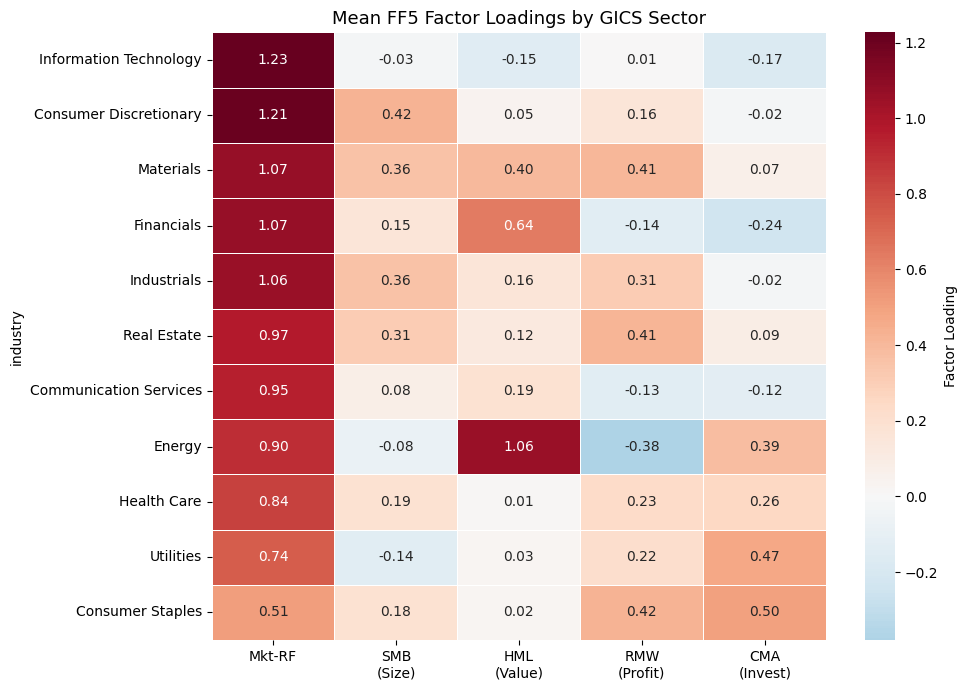

In [12]:
# ── Compute mean FF5 factor loadings by sector ─────────────────────────────────
factor_cols = ['FF5_Beta_Mkt', 'FF5_Beta_SMB', 'FF5_Beta_HML', 'FF5_Beta_RMW', 'FF5_Beta_CMA']
sector_loadings = (
    all_results
    .groupby('industry')[factor_cols]
    .mean()
    .round(3)
    .sort_values('FF5_Beta_Mkt', ascending=False)  # sort by market beta
)

# ── Heatmap — compact way to show all 5 loadings × 11 sectors at once ─────────
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    sector_loadings,
    annot=True,            # show values in each cell
    fmt='.2f',             # 2 decimal places
    cmap='RdBu_r',         # red = positive, blue = negative
    center=0,              # white at zero
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Factor Loading'}
)
ax.set_title('Mean FF5 Factor Loadings by GICS Sector', fontsize=13)
ax.set_xlabel('')
ax.set_xticklabels(
    ['Mkt-RF', 'SMB\n(Size)', 'HML\n(Value)', 'RMW\n(Profit)', 'CMA\n(Invest)'],
    rotation=0
)
plt.tight_layout()
plt.show()

## 9d. CAPM Beta vs FF5 Market Beta

When we control for the extra factors (size, value, profitability, investment), the estimated **market beta** can change.

- Points on the **diagonal** → adding factors didn't change the market beta much
- Points **above** the diagonal → FF5 market beta is higher (CAPM was underestimating)
- Points **below** the diagonal → FF5 market beta is lower (CAPM was overestimating)

Large deviations often occur for small-cap or value stocks where size/value exposures partly explain what CAPM attributed to market sensitivity.

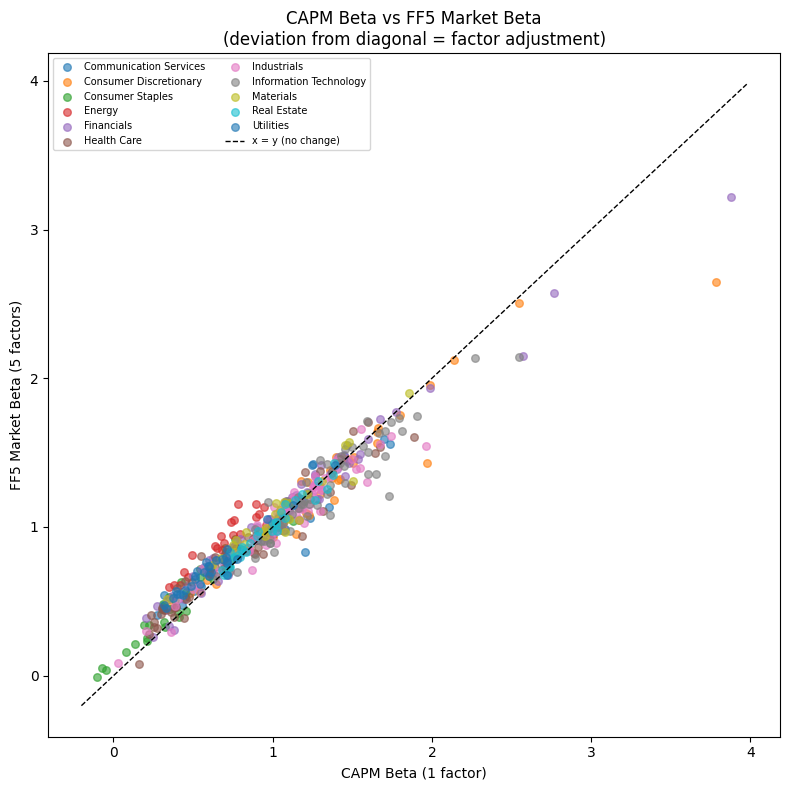

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

# Colour each point by sector
for sector, grp in all_results.groupby('industry'):
    ax.scatter(
        grp['CAPM_Beta'], grp['FF5_Beta_Mkt'],
        label=sector, alpha=0.6, s=30
    )

# 45-degree reference line (x = y means identical betas)
lims = [all_results[['CAPM_Beta', 'FF5_Beta_Mkt']].min().min() - 0.1,
        all_results[['CAPM_Beta', 'FF5_Beta_Mkt']].max().max() + 0.1]
ax.plot(lims, lims, 'k--', linewidth=1, label='x = y (no change)')

ax.set_xlabel('CAPM Beta (1 factor)')
ax.set_ylabel('FF5 Market Beta (5 factors)')
ax.set_title('CAPM Beta vs FF5 Market Beta\n(deviation from diagonal = factor adjustment)', fontsize=12)
ax.legend(loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

In [30]:
plot_df = all_results.reset_index()
ticker_col = 'Ticker' if 'Ticker' in plot_df.columns else 'index'
plot_df['Label'] = plot_df[ticker_col] + ' | ' + plot_df['Security']

# Rename to display-friendly labels — Plotly uses the column name as the hover label,
# so the name here controls both what's shown and the order they appear
plot_df = plot_df.rename(columns={
    'CAPM_R2': 'CAPM R²',
    'FF3_R2':  'FF3 R²',
    'FF5_R2':  'FF5 R²',
})

sector_order = (
    plot_df.groupby('industry')['FF5 R²']
    .mean().sort_values(ascending=False)
    .index.tolist()
)

fig = px.strip(
    plot_df,
    x='FF5 R²',
    y='industry',
    color='industry',
    orientation='h',
    hover_name='Label',
    hover_data={
        'Label':    False,
        'industry': False,
        'FF5 R²':   False,  # hidden — shown via hover_name position
        'CAPM R²':  ':.3f',
        'FF3 R²':   ':.3f',
        'FF5 R²':   ':.3f',
    },
    category_orders={'industry': sector_order},
    title='FF5 R² by Sector',
)

fig.update_traces(
    jitter=1, pointpos=0,
    marker=dict(size=9, opacity=0.7, line=dict(width=0.5, color='white')),
)

fig.update_layout(
    height=800,
    template='plotly_white',
    showlegend=False,
    xaxis_title='FF5 R²',
    yaxis_title='',
)

fig.add_vline(x=0.5, line_dash='dash', line_color='grey', line_width=1,
              annotation_text='R²=0.5', annotation_position='top')

fig.show()

## 10. Sector-Level Summary Tables

### CAPM Beta by Sector

In [13]:
print("--- CAPM Beta Summary by GICS Sector ---")
capm_sector = (
    all_results
    .groupby('industry')['CAPM_Beta']
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
    .round(2)
)
display(capm_sector)

print("\n--- FF5 Market Beta Summary by GICS Sector ---")
ff5_sector = (
    all_results
    .groupby('industry')['FF5_Beta_Mkt']
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
    .round(2)
)
display(ff5_sector)

print("\n--- Mean R² by Sector and Model ---")
r2_sector = (
    all_results
    .groupby('industry')[['CAPM_R2', 'FF3_R2', 'FF5_R2']]
    .mean()
    .sort_values('FF5_R2', ascending=False)
    .round(3)
)
display(r2_sector)

--- CAPM Beta Summary by GICS Sector ---


,count,mean,std,min,max
industry,,,,,
Information Technology,69,1.27,0.36,0.64,2.54
Consumer Discretionary,48,1.25,0.58,0.36,3.78
Industrials,77,1.07,0.34,0.03,1.96
Financials,75,1.04,0.59,0.21,3.88
Materials,26,1.02,0.32,0.34,1.85
Communication Services,23,0.96,0.41,0.27,1.73
Real Estate,31,0.96,0.22,0.68,1.38
Health Care,59,0.81,0.45,0.16,1.89
Energy,22,0.69,0.19,0.35,0.96



--- FF5 Market Beta Summary by GICS Sector ---


,count,mean,std,min,max
industry,,,,,
Information Technology,69,1.23,0.32,0.67,2.14
Consumer Discretionary,48,1.21,0.46,0.47,2.65
Materials,26,1.07,0.29,0.51,1.90
Financials,75,1.07,0.49,0.26,3.22
Industrials,77,1.06,0.30,0.09,1.66
Real Estate,31,0.97,0.21,0.68,1.43
Communication Services,23,0.95,0.34,0.41,1.59
Energy,22,0.90,0.18,0.59,1.16
Health Care,59,0.84,0.39,0.08,1.71



--- Mean R² by Sector and Model ---


,CAPM_R2,FF3_R2,FF5_R2
industry,,,
Financials,0.318,0.479,0.509
Industrials,0.362,0.431,0.466
Real Estate,0.349,0.416,0.452
Materials,0.293,0.400,0.443
Consumer Discretionary,0.302,0.362,0.406
Energy,0.109,0.382,0.404
Information Technology,0.321,0.375,0.401
Communication Services,0.217,0.300,0.332
Utilities,0.184,0.278,0.328


## 11. Key Takeaways

After working through this notebook you should be able to:

1. **Explain the Fama-French factors** — SMB (size), HML (value), RMW (profitability), CMA (investment) and the intuition behind each.
2. **Source factor data** — Kenneth French's data library is the canonical, free source.
3. **Align factor data with stock data** — matching dates, computing excess returns, handling NaNs.
4. **Compare models on R²** — FF3 and FF5 typically explain more variance than CAPM alone.
5. **Interpret factor loadings** — what it means for a stock or sector to have a positive SMB or negative HML loading.
6. **See how market beta changes** — controlling for size and value often shifts the estimated market beta.

---

### 🔭 Extensions to Try

- **Rolling factor loadings** — compute betas on a 36-month rolling window to see style drift over time
- **Carhart 4-factor model** — add momentum (WML, Winners Minus Losers) as a fourth factor
- **Portfolio construction** — build a "pure size" or "pure value" portfolio by targeting specific factor loadings
- **Factor timing** — do certain sectors' loadings change predictably before/after recessions?

### 📚 Further Reading

- [Fama & French (1993) — Common risk factors in stock returns](https://doi.org/10.1016/0304-405X(93)90023-5)
- [Fama & French (2015) — A five-factor asset pricing model](https://doi.org/10.1016/j.jfineco.2014.10.010)
- [French's Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html)
- [CAPM — Investopedia](https://www.investopedia.com/terms/c/capm.asp)
- [yfinance documentation](https://ranaroussi.github.io/yfinance/)
- [statsmodels OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html)
